<a href="https://colab.research.google.com/github/Ezgicode/FlyRAnk-AI/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ezgicode/FlyRAnk-AI/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Ranked content actions

This playbook turns measured search-performance signals into a ranked queue for human review. It is a decision-support tool, not an automatic editing system.

Each row is a pseudonymized content page. The priority score is based only on signals available during the first 15 days of March 2026: impressions, clicks, average position, CTR, and active days. The later period is used only to train and evaluate the historical decline proxy; it is not an input to the action score.

The ranked queue can produce three practical action labels:

- **content_refresh_brief** — a visible page in positions 21–50 with a weak CTR pattern. Review the content’s topical coverage, structure, freshness, internal links, and search intent.
- **title_snippet_review** — a visible page already near page one or two with relatively weak CTR. Review the title, meta description, SERP snippet, and intent match before changing the full content.
- **human_refresh_review** — a visible page whose measured signals justify editorial review, but where the most appropriate intervention is not yet clear.

Reason codes describe why a page entered the queue. They are explanations for a reviewer, not claims that a specific change will recover traffic.

The refresh insight is directional: a page with meaningful visibility and weak engagement or a less competitive position may be worth reviewing before its potential audience is lost. A refresh should be approved only after human inspection of content quality, intent, business value, and technical conditions.

In [ ]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib

In [ ]:
import os
import getpass
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

print("Token loaded safely.")

Token loaded safely.


In [ ]:
con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

MARCH = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

feature_frame = con.sql(f"""
    WITH page_windows AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(
                CASE WHEN report_date BETWEEN DATE '2026-03-01'
                                     AND DATE '2026-03-15'
                THEN gsc_impressions ELSE 0 END
            ) AS prior_15d_impressions,

            SUM(
                CASE WHEN report_date BETWEEN DATE '2026-03-01'
                                     AND DATE '2026-03-15'
                THEN gsc_clicks ELSE 0 END
            ) AS prior_15d_clicks,

            AVG(
                CASE WHEN report_date BETWEEN DATE '2026-03-01'
                                     AND DATE '2026-03-15'
                THEN gsc_avg_position END
            ) AS prior_15d_avg_position,

            COUNT(DISTINCT
                CASE WHEN report_date BETWEEN DATE '2026-03-01'
                                     AND DATE '2026-03-15'
                THEN report_date END
            ) AS prior_15d_active_days,

            SUM(
                CASE WHEN report_date BETWEEN DATE '2026-03-16'
                                     AND DATE '2026-03-31'
                THEN gsc_impressions ELSE 0 END
            ) AS next_16d_impressions

        FROM {MARCH}
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )

    SELECT
        *,
        CASE
            WHEN prior_15d_impressions > 0
            THEN prior_15d_clicks / prior_15d_impressions
            ELSE 0
        END AS prior_15d_ctr,

        CASE
            WHEN prior_15d_impressions >= 100
             AND next_16d_impressions <= 0.80 * prior_15d_impressions
            THEN 1
            ELSE 0
        END AS is_next_15d_declining

    FROM page_windows
    WHERE prior_15d_impressions >= 100
""").df()

feature_columns = [
    "prior_15d_impressions",
    "prior_15d_clicks",
    "prior_15d_avg_position",
    "prior_15d_ctr",
    "prior_15d_active_days"
]

model_df = feature_frame.dropna(subset=feature_columns).copy()

playbook_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# The future-window proxy is used only as the historical training label,
# never as a score input.
playbook_model.fit(
    model_df[feature_columns],
    model_df["is_next_15d_declining"]
)

model_df["priority_score"] = playbook_model.predict_proba(
    model_df[feature_columns]
)[:, 1]

def choose_action(row):
    if 21 <= row["prior_15d_avg_position"] <= 50:
        return "content_refresh_brief"
    if 4 <= row["prior_15d_avg_position"] <= 20:
        return "title_snippet_review"
    return "human_refresh_review"

def choose_reason(row):
    if 21 <= row["prior_15d_avg_position"] <= 50:
        return "visible_position_21_50_opportunity"
    if row["prior_15d_ctr"] < 0.01:
        return "visible_low_ctr_opportunity"
    return "measured_decline_risk_for_human_review"

model_df["action_label"] = model_df.apply(choose_action, axis=1)
model_df["reason_code"] = model_df.apply(choose_reason, axis=1)

ranked_queue = (
    model_df
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True)
)

ranked_queue["rank"] = ranked_queue.index + 1

queue_columns = [
    "rank",
    "content_hash_id",
    "action_label",
    "reason_code",
    "priority_score",
    "prior_15d_impressions",
    "prior_15d_clicks",
    "prior_15d_avg_position",
    "prior_15d_ctr",
    "prior_15d_active_days"
]

print(f"Ranked queue rows: {len(ranked_queue):,}")
print("Top-20 action distribution:")
display(
    ranked_queue.head(20)["action_label"]
    .value_counts()
    .rename_axis("action_label")
    .reset_index(name="pages")
)

display(ranked_queue[queue_columns].head(20).round(4))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Ranked queue rows: 77,540
Top-20 action distribution:


,action_label,pages
0,content_refresh_brief,10
1,title_snippet_review,9
2,human_refresh_review,1


,rank,content_hash_id,action_label,reason_code,priority_score,prior_15d_impressions,prior_15d_clicks,prior_15d_avg_position,prior_15d_ctr,prior_15d_active_days
0,1,content_9c057b66c30a3abb,title_snippet_review,visible_low_ctr_opportunity,0.9963,83772.0,0.0,8.6079,0.0000,15
1,2,content_34a70fea29d15f24,human_refresh_review,visible_low_ctr_opportunity,0.9875,73639.0,18.0,2.7867,0.0002,15
2,3,content_559cdd76da9306de,content_refresh_brief,visible_position_21_50_opportunity,0.9863,62418.0,2.0,37.8661,0.0000,15
3,4,content_7c6373141eae744a,title_snippet_review,visible_low_ctr_opportunity,0.9857,86860.0,51.0,5.7855,0.0006,15
4,5,content_bdf60c86117079be,content_refresh_brief,visible_position_21_50_opportunity,0.9807,60277.0,8.0,31.0463,0.0001,15
5,6,content_8e1334d6356668e3,title_snippet_review,visible_low_ctr_opportunity,0.9805,58553.0,1.0,4.5790,0.0000,15
6,7,content_36e53e9c707674fc,content_refresh_brief,visible_position_21_50_opportunity,0.9804,109909.0,115.0,33.3544,0.0010,15
7,8,content_82e35c4845e6c391,title_snippet_review,visible_low_ctr_opportunity,0.9797,70169.0,29.0,18.2696,0.0004,15
8,9,content_9d1e94cbd32b0a41,content_refresh_brief,visible_position_21_50_opportunity,0.9675,50780.0,6.0,35.0563,0.0001,15
9,10,content_65c75874a23fca87,title_snippet_review,visible_low_ctr_opportunity,0.9654,55680.0,15.0,9.0135,0.0003,15


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

The intended user is a content editor, SEO analyst, or content strategist planning a limited review queue. The output helps them decide which pages to inspect first when there are more possible pages than review capacity.

The queue supports prioritisation, not diagnosis. A high score does not prove that a page will decline, that the content is poor, or that a refresh will increase traffic. It only represents a measured pattern in this historical March 2026 slice.

The model was evaluated with a grouped client holdout in the previous notebook. On that honest split, Logistic Regression measured Precision@50 of 0.28, compared with 0.14 for the hand-written baseline. This is directional evidence for ranking support, not a production-quality guarantee.

The playbook is limited to pages with available search data and at least 100 impressions in the first 15 days. It does not use conversions, revenue, editorial effort estimates, content quality assessments, seasonality, competitor changes, query intent, or technical SEO diagnostics. Therefore, a person must combine the score with context before selecting an action.

In [ ]:
intended_use_limits = pd.DataFrame([
    {
        "area": "Intended user",
        "playbook position": "Content editor, SEO analyst, or content strategist"
    },
    {
        "area": "Primary use",
        "playbook position": "Rank pages for limited human review capacity"
    },
    {
        "area": "Observed validation evidence",
        "playbook position": (
            "Grouped client holdout: Logistic Regression Precision@50 = 0.28; "
            "hand-written baseline Precision@50 = 0.14"
        )
    },
    {
        "area": "Not measured",
        "playbook position": (
            "Conversions, revenue, content quality, seasonality, query intent, "
            "technical issues, competitors, and refresh effort"
        )
    },
    {
        "area": "Scope limit",
        "playbook position": (
            "March 2026 historical slice; pages with available data and at least "
            "100 prior-period impressions"
        )
    }
])

display(intended_use_limits)

,area,playbook position
0,Intended user,"Content editor, SEO analyst, or content strate..."
1,Primary use,Rank pages for limited human review capacity
2,Observed validation evidence,Grouped client holdout: Logistic Regression Pr...
3,Not measured,"Conversions, revenue, content quality, seasona..."
4,Scope limit,March 2026 historical slice; pages with availa...


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human-review rules

A reviewer must inspect the page, the relevant queries, the current search-result page, and the content’s business purpose before acting. The reviewer should decide whether the page needs a title/snippet experiment, a content refresh brief, no action, or a separate technical investigation.

Cost and value matter. A page with high visibility may be worth deeper review, but a costly rewrite should not be selected solely because of its score. Expected value should be considered alongside likely editorial effort, page importance, conversion context where available, and the possibility of a smaller intervention.

### No-go list: what must not be automated

This playbook must not automatically publish content changes, rewrite titles or meta descriptions, delete or merge pages, change internal links, modify structured data, change canonical tags, or treat a prediction as proof that a decline will occur.

It also must not score pages using future-window outcomes, label-derived columns, existing product flags, client identifiers, or content identifiers. These fields would either leak future information or reproduce an earlier decision rather than provide an honest recommendation.

In [ ]:
human_review_rules = pd.DataFrame([
    {
        "review_step": "Inspect search intent and current SERP",
        "why_it_matters": (
            "Low CTR can be appropriate for some query types or affected by "
            "SERP features outside the page."
        )
    },
    {
        "review_step": "Check content quality, freshness, and topic coverage",
        "why_it_matters": (
            "The score cannot read the page or determine whether its information "
            "is outdated."
        )
    },
    {
        "review_step": "Estimate cost and expected value",
        "why_it_matters": (
            "A high-scoring page may not justify a costly rewrite if its business "
            "value is low."
        )
    },
    {
        "review_step": "Choose and document the intervention",
        "why_it_matters": (
            "Human reviewers should distinguish a snippet test, refresh brief, "
            "technical investigation, or no-action decision."
        )
    }
])

no_go_list = pd.DataFrame({
    "must_not_be_automated": [
        "Publishing or rewriting content",
        "Changing titles, meta descriptions, or internal links",
        "Deleting, merging, or canonicalising pages",
        "Treating the score as proof of future decline",
        "Using future-window or label-derived fields as features"
    ]
})

print("Required human-review checks:")
display(human_review_rules)

print("No-go list:")
display(no_go_list)

Required human-review checks:


,review_step,why_it_matters
0,Inspect search intent and current SERP,Low CTR can be appropriate for some query type...
1,"Check content quality, freshness, and topic co...",The score cannot read the page or determine wh...
2,Estimate cost and expected value,A high-scoring page may not justify a costly r...
3,Choose and document the intervention,Human reviewers should distinguish a snippet t...


No-go list:


,must_not_be_automated
0,Publishing or rewriting content
1,"Changing titles, meta descriptions, or interna..."
2,"Deleting, merging, or canonicalising pages"
3,Treating the score as proof of future decline
4,Using future-window or label-derived fields as...


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring and retrain triggers

This is a small historical decision-support prototype, so monitoring should be lightweight and practical.

For each review cycle, the team should record which recommended pages were actually reviewed, which action was chosen, and what later search-performance pattern was observed. The measured Precision@20 and Precision@50 of the queue should be compared with its historical grouped-holdout reference.

A retrain or rule review is triggered when one of the following happens:

- Measured Precision@50 stays materially below the historical grouped-holdout reference for two review cycles.
- The rate of pages with missing or unavailable search data increases.
- The distributions of impressions, CTR, position, or active days shift materially from the training slice.
- Search-result layouts, tracking definitions, content strategy, or business priorities change.
- Reviewers repeatedly identify a reason the queue cannot represent, such as seasonal demand, technical indexing problems, or intent mismatch.

Retraining is not automatic. A person should first check data quality, label definition, and changes in the review process.

In [ ]:
monitoring_plan = pd.DataFrame([
    {
        "monitor": "Queue precision",
        "measure": "Precision@20 and Precision@50 after the later outcome window closes",
        "review_or_retrain_trigger": (
            "Precision@50 remains materially below the grouped-holdout reference "
            "for two review cycles"
        )
    },
    {
        "monitor": "Data availability",
        "measure": "Share of expected pages with available search data",
        "review_or_retrain_trigger": (
            "Availability falls or missingness changes materially"
        )
    },
    {
        "monitor": "Feature drift",
        "measure": "Distribution of impressions, CTR, position, and active days",
        "review_or_retrain_trigger": (
            "Feature distributions shift materially from the March 2026 slice"
        )
    },
    {
        "monitor": "Editorial feedback",
        "measure": "Reviewer reasons for rejecting or changing recommendations",
        "review_or_retrain_trigger": (
            "Repeated uncaptured causes such as seasonality, technical issues, "
            "or intent mismatch"
        )
    }
])

display(monitoring_plan)

,monitor,measure,review_or_retrain_trigger
0,Queue precision,Precision@20 and Precision@50 after the later ...,Precision@50 remains materially below the grou...
1,Data availability,Share of expected pages with available search ...,Availability falls or missingness changes mate...
2,Feature drift,"Distribution of impressions, CTR, position, an...",Feature distributions shift materially from th...
3,Editorial feedback,Reviewer reasons for rejecting or changing rec...,Repeated uncaptured causes such as seasonality...


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Exports

The notebook writes a reproducible ranked action queue to `work/outputs/` and a reusable figure to `work/figures/`. The CSV contains pseudonymized page identifiers and is intentionally not committed to the public repository. The figure and metrics JSON are safe receipts for the later research paper because they contain only aggregated public-safe information.

The exported queue is an offline demonstration based on a historical data slice. It must be regenerated from approved data before any future review cycle.

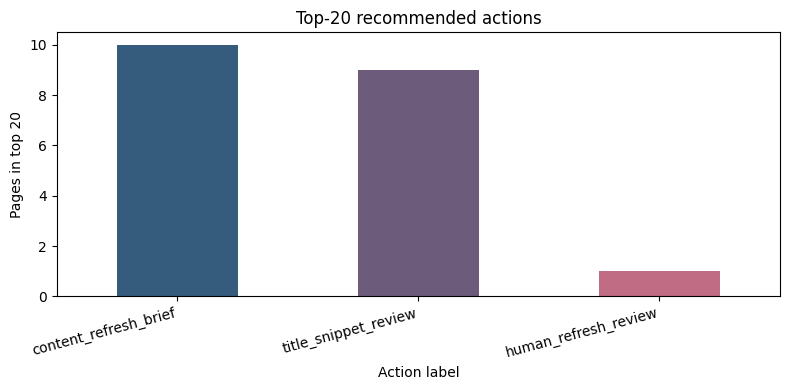

Queue written: work/outputs/action_playbook_queue.csv
Metrics receipt written: work/outputs/action_playbook_metrics.json
Reusable figure written: work/figures/action_playbook_top20_actions.png


,data_window,queue_rows,top20_rows,historical_grouped_holdout_precision_at_20,historical_grouped_holdout_precision_at_50,historical_grouped_holdout_base_rate,action_distribution_top20,final_feature_columns,excluded_future_fields,intended_use
0,March 2026; signals from March 1-15,77540,20,0.15,0.28,0.148,"{'content_refresh_brief': 10, 'title_snippet_r...","[prior_15d_impressions, prior_15d_clicks, prio...","[next_16d_impressions, is_next_15d_declining]",Human review prioritisation only; not automati...


In [ ]:
import json

output_dir = Path("work/outputs")
figure_dir = Path("work/figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

queue_path = output_dir / "action_playbook_queue.csv"
metrics_path = output_dir / "action_playbook_metrics.json"
figure_path = figure_dir / "action_playbook_top20_actions.png"

# The queue remains uncommitted because it contains row-level data.
ranked_queue[queue_columns].to_csv(queue_path, index=False)

top20_actions = (
    ranked_queue.head(20)["action_label"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
top20_actions.plot(kind="bar", color=["#355C7D", "#6C5B7B", "#C06C84"])
plt.title("Top-20 recommended actions")
plt.xlabel("Action label")
plt.ylabel("Pages in top 20")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(figure_path, dpi=180)
plt.show()

playbook_metrics = {
    "data_window": "March 2026; signals from March 1-15",
    "queue_rows": int(len(ranked_queue)),
    "top20_rows": 20,
    "historical_grouped_holdout_precision_at_20": 0.15,
    "historical_grouped_holdout_precision_at_50": 0.28,
    "historical_grouped_holdout_base_rate": 0.148,
    "action_distribution_top20": {
        str(action): int(count)
        for action, count in top20_actions.items()
    },
    "final_feature_columns": feature_columns,
    "excluded_future_fields": [
        "next_16d_impressions",
        "is_next_15d_declining"
    ],
    "intended_use": "Human review prioritisation only; not automatic publishing."
}

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(playbook_metrics, file, indent=2)

print(f"Queue written: {queue_path}")
print(f"Metrics receipt written: {metrics_path}")
print(f"Reusable figure written: {figure_path}")

display(pd.DataFrame([playbook_metrics]))

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.